# Téléchargement et exploration des données

In [119]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets
import plotly.express as px
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [51]:
# Download data
data_dir = './nilearn_data' # ajout de l'endroit pour télécharger data, plus facile à répliquer ensuite
data = datasets.fetch_adhd(n_subjects=40, data_dir = data_dir) # prend tout le dataset disponible contrairement à étude original

[fetch_adhd] Dataset found in nilearn_data/adhd


In [53]:
# Type de données dans notre data set
data.keys()

dict_keys(['func', 'confounds', 'phenotypic', 'description', 't_r'])

In [54]:
# Transformation de phenotypes en taableau
pheno = pd.DataFrame(data.phenotypic)

In [55]:
# Tous les types de données phénotype possible
pheno.columns 

Index(['Unnamed: 0', 'Subject', 'Rest.Scan', 'MeanFD',
       'NumFD_greater_than_0.20', 'rootMeanSquareFD', 'FDquartile.top1.4thFD.',
       'PercentFD_greater_than_0.20', 'MeanDVARS', 'MeanFD_Jenkinson', 'site',
       'sibling_id', 'data_set', 'age', 'sex', 'handedness', 'full_2_iq',
       'full_4_iq', 'viq', 'piq', 'iq_measure', 'tdc', 'adhd',
       'adhd_inattentive', 'adhd_combined', 'adhd_subthreshold',
       'diagnosis_using_cdis', 'notes', 'sess_1_anat_2', 'oppositional',
       'cog_inatt', 'hyperac', 'anxious_shy', 'perfectionism',
       'social_problems', 'psychosomatic', 'conn_adhd', 'restless_impulsive',
       'emot_lability', 'conn_gi_tot', 'dsm_iv_inatt', 'dsm_iv_h_i',
       'dsm_iv_tot', 'study', 'sess_1_rest_1', 'sess_1_rest_1_eyes',
       'sess_1_rest_2', 'sess_1_rest_2_eyes', 'sess_1_rest_3',
       'sess_1_rest_3_eyes', 'sess_1_rest_4', 'sess_1_rest_4_eyes',
       'sess_1_rest_5', 'sess_1_rest_5_eyes', 'sess_1_rest_6',
       'sess_1_rest_6_eyes', 'sess_1_a

In [56]:
# Vérifier combien de participants ont des données phéno
len(pheno) 

30

Il est anormale que notre dataframe pheno a seulement 30 participants (donc la fonction data.phenotypic ne fonctionne pas correctement). On doit ainsi aller manuellement chercher les données phénotypes pour avoir tous les 40 participants

In [57]:
pheno_all = pd.read_csv('nilearn_data/adhd/ADHD200_40subs_motion_parameters_and_phenotypics.csv')

On va regarder les distributions pour les 30 participants et les 40 participants pour visualiser les différences

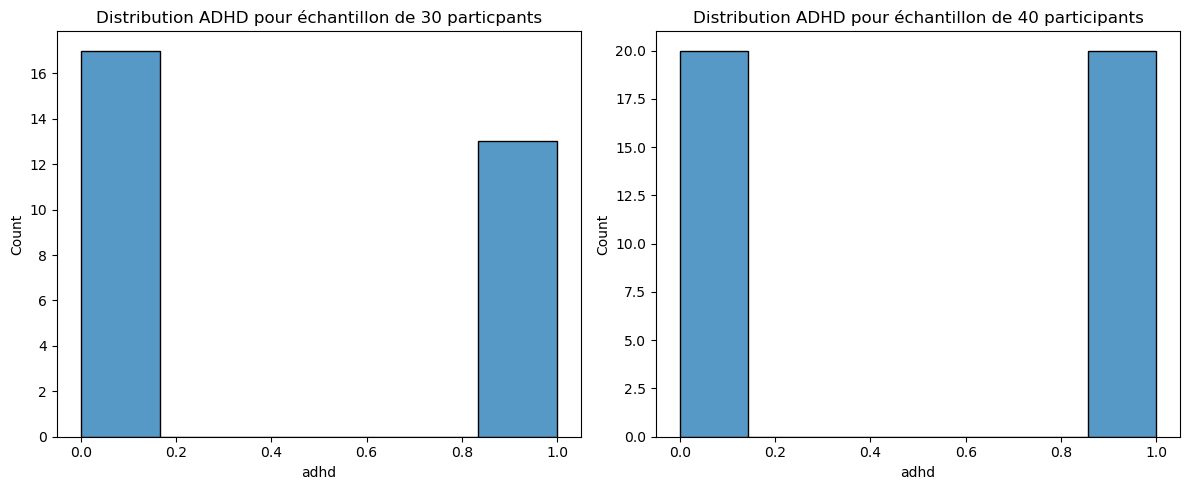

In [59]:
# Regarder la distribution des diagnostics de TDAH
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# échantillon de 30 personnes
sns.histplot(pheno['adhd'], ax=ax1)
ax1.set_title("Distribution ADHD pour échantillon de 30 particpants")

# échantillon de 40 personnes
sns.histplot(pheno_all['adhd'], ax=ax2)
ax2.set_title("Distribution ADHD pour échantillon de 40 participants")

plt.tight_layout()
plt.show()

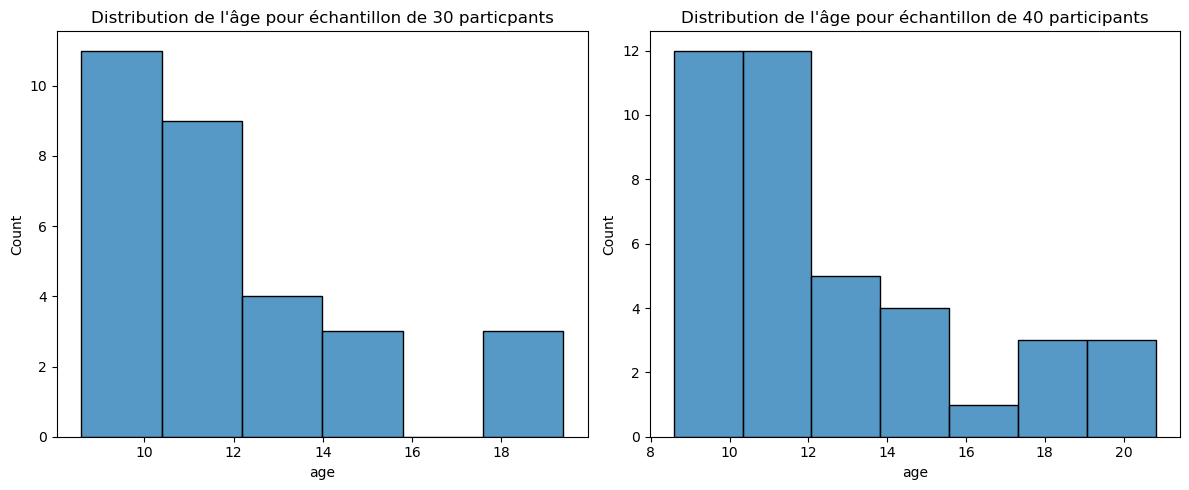

In [61]:
# Regarder la distribution d'âge
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# échantillon de 30 personnes
sns.histplot(pheno['age'], ax=ax1)
ax1.set_title("Distribution de l'âge pour échantillon de 30 particpants")

# échantillon de 40 personnes
sns.histplot(pheno_all['age'], ax=ax2)  
ax2.set_title("Distribution de l'âge pour échantillon de 40 participants")

plt.tight_layout()
plt.show()

In [63]:
# Identifier les sujets manquants de l'échantillon de 30 participants
manquants = set(pheno_all['Subject']) - set(pheno['Subject'])
print(manquants)

{23008, 27011, 23012, 27018, 10128, 10064, 27034, 21019, 10042, 27037}


In [72]:
# Comparaison avec les sujets du projet original
pheno_original = pd.read_csv('projet_original/pheno_table.csv')

diff_pheno40 = set(pheno_all['Subject']) - set(pheno_original['Subject'])
diff_pheno30 = set(pheno['Subject']) - set(pheno_original['Subject'])

print(diff_pheno40)
print(diff_pheno30)

{4134561, 7774305, 4275075, 9750701, 8697774, 9744150, 4046678, 4164316, 6115230, 8409791}
{4134561, 7774305, 4275075, 9750701, 8697774, 9744150, 4046678, 4164316, 6115230, 8409791}


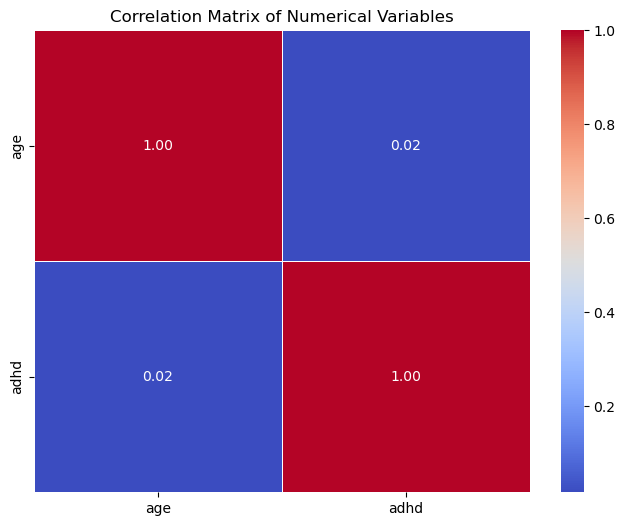

In [88]:
# Matrice de corrélation de l'âge et du diagnostic TDAH 
numerical_cols = ['age', 'adhd']
df_numeric = pheno_all[numerical_cols]

# Compute the correlation matrix
correlation_matrix = df_numeric.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

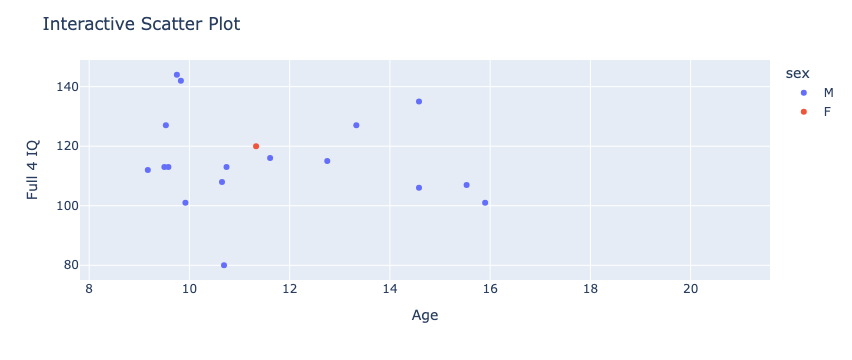

In [84]:
# Reproduction du scatter plot
fig = px.scatter(pheno_all, x='age', y='full_4_iq', color='sex', hover_data=['adhd', 'cog_inatt', 'hyperac', 'anxious_shy', 'perfectionism',
       'social_problems','conn_adhd', 'restless_impulsive',])

fig.update_layout(
    title="Interactive Scatter Plot",
    xaxis_title="Age",
    yaxis_title="Full 4 IQ"
)

fig.show()

In [85]:
# Vérification de pourquoi graphique différent que projet initial
print(pheno_all[['age', 'full_4_iq']].isna().sum())

age           0
full_4_iq    22
dtype: int64



Contrairement au projet original, l'utilisation de son code ne montre pas les participants qui n'ont pas de valeur au full_4_iq (notre graphique présente 22 participants de moins). Je préfère cette visualisation que l'original qui met un peu arbitrairement les données manquantes au milieu du graphique, induisant un peu en erreur l'interprétation de la figure


# Préparation des données

In [89]:
from nilearn.input_data import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import plotting
from nilearn import image
from nilearn.plotting import plot_connectome

/var/folders/rw/8w59v3ld03q_jn0m9p0qxr1r0000gn/T/ipykernel_51860/2884611696.py:1: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker


## Extraction des features

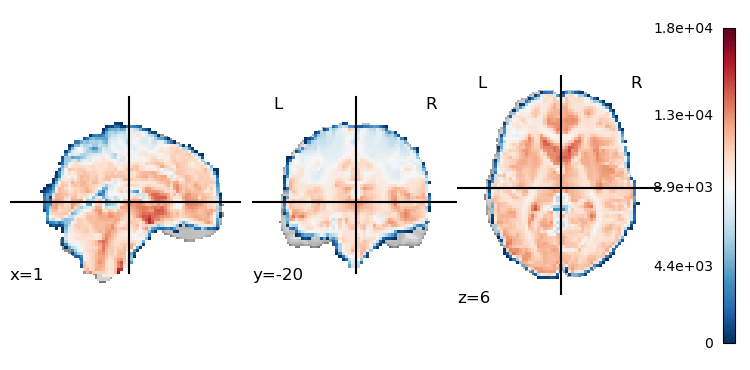

In [99]:
# Image moyenne pour séries temporelles d'un sujet
fmri_filenames = data.func[0]
averaged_Img = image.mean_img(fmri_filenames)
plotting.plot_stat_map(averaged_Img)

La visualisation est différente du projet initial, sûrement du au fait que notre participant 1 n'est peut-être pas le même participant 1.

In [110]:
#Importer l'atlas
parcellations = datasets.fetch_atlas_basc_multiscale_2015(version='sym', resolution=64) 
atlas_filename = parcellations.maps 

[fetch_atlas_basc_multiscale_2015] Dataset found in /Users/anhthinguyen/nilearn_data/basc_multiscale_2015


MODIFICATION: Avec le présente version de nilearn, on doit maintenant préciser quelle résolution on veut lorsqu'on fetch l'atlas, semble qu'ancienne version retournait toutes les versions en même temps. Les keys ont également changer, donc on doit faire parcellations.maps pour avoir le file_name de l'atlas

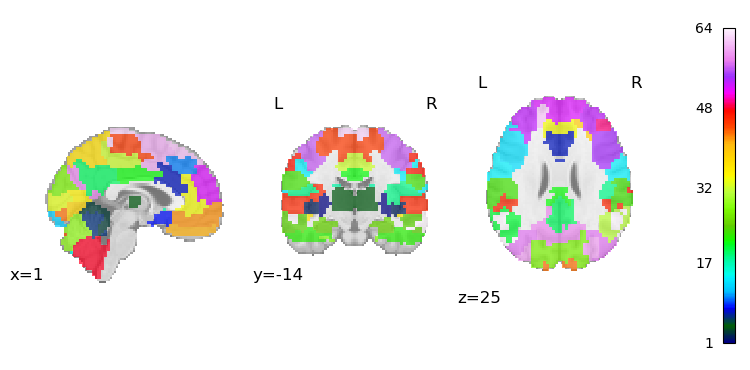

In [111]:
#Plot atlas
plotting.plot_roi(atlas_filename, draw_cross = False)

In [116]:
# Création du masque
mask = NiftiLabelsMasker(labels_img=atlas_filename, 
                           standardize='zscore_sample', #standardize = True est deprecated et donne pleins de warnings
                           memory='nilearn_cache', 
                           verbose=0)

# Initialisation de la mesure de corrélation
correlation_measure = ConnectivityMeasure(kind='correlation', vectorize=True,
                                         discard_diagonal=True, standardize = 'zscore_sample')

In [124]:
print(all_features[0].shape)

(2016,)


In [120]:
# Matrice de corrélation pour tous les sujets
all_features= []

for i, sub in enumerate(data.func):
    # Extract the timeseries from the ROIs in the atlas
    time_series = mask.fit_transform(sub, confounds=data.confounds[i])
    
    # Create a region x region correlation matrix
    # correlation_measure = ConnectivityMeasure(kind='correlation') pas besoin de réinitialiser à chaque ittération
    correlation_matrix = correlation_measure.fit_transform([time_series])[0]
    
    # Append features and file name to the list
    all_features.append(correlation_matrix)
    print('finished %s of %s'%(i+1, len(data.func)))

finished 1 of 40
finished 2 of 40
finished 3 of 40
finished 4 of 40
finished 5 of 40
finished 6 of 40
finished 7 of 40
finished 8 of 40
finished 9 of 40
finished 10 of 40
finished 11 of 40
finished 12 of 40
finished 13 of 40
finished 14 of 40
finished 15 of 40
finished 16 of 40
finished 17 of 40
finished 18 of 40
finished 19 of 40
finished 20 of 40
finished 21 of 40
finished 22 of 40
finished 23 of 40
finished 24 of 40
finished 25 of 40
finished 26 of 40
finished 27 of 40
finished 28 of 40
finished 29 of 40
finished 30 of 40
finished 31 of 40
finished 32 of 40
finished 33 of 40
finished 34 of 40
finished 35 of 40
finished 36 of 40
finished 37 of 40
finished 38 of 40
finished 39 of 40
finished 40 of 40


In [123]:
#Flattened matrix for use
flattened_features = [arr.flatten() for arr in all_features]
print(flattened_features)

[array([ 0.38576007,  0.1975293 , -0.03456974, ...,  0.1975504 ,
        0.03095824,  0.16718616], shape=(2016,), dtype=float32), array([ 0.05906582,  0.02325726,  0.23092335, ...,  0.40791136,
        0.09483441, -0.15675311], shape=(2016,), dtype=float32), array([ 0.46423674, -0.0555926 , -0.18878943, ...,  0.54118514,
       -0.5111481 ,  0.08249143], shape=(2016,), dtype=float32), array([ 0.2942519 ,  0.03405671,  0.10205512, ...,  0.5268332 ,
       -0.38508448,  0.08321011], shape=(2016,), dtype=float32), array([-0.03144473,  0.14899744,  0.2290162 , ...,  0.35301188,
       -0.1914968 ,  0.05912467], shape=(2016,), dtype=float32), array([ 0.29637885, -0.30574092, -0.20158528, ...,  0.50451875,
       -0.13461493,  0.3762568 ], shape=(2016,), dtype=float32), array([ 0.2435921 ,  0.03613283,  0.08876574, ...,  0.13204144,
       -0.04890551,  0.20230024], shape=(2016,), dtype=float32), array([-0.01770267, -0.03214461, -0.23188333, ..., -0.05991179,
        0.03936002, -0.038204  ]

In [122]:
#Plot correlation matric for one subject 
correlation_matrix = all_features[0]
np.fill_diagonal(correlation_matrix, 0)

plotting.plot_matrix(correlation_matrix, figure=(10, 8),
                     labels=range(correlation_matrix.shape[0]),
                     vmax=0.8, vmin=-0.8, reorder=False)

ValueError: array must be at least 2-d